# 03 – Baseline: globaler Z-Score auf dem STL-Residuum

Einfachste, voll erklärbare Anomalieerkennung (3-Sigma-Regel) als **Maßstab** für die
komplexeren Verfahren. Eingang ist **`stl_resid`** aus `features.parquet` (Saison/Trend
und – wie in `02_features.ipynb` gezeigt – auch das Wettersignal sind bereits entfernt;
das Residuum misst die „Untypischkeit für diesen Zeitpunkt").

Z-Score **pro Zähler** (Standardisierung ist verteilungsbezogen, Residuenverteilung je
Zähler verschieden) und **global** über die volle Historie (bewusst simpel; STL hat den
Trend bereits absorbiert, daher kein rollendes Fenster nötig).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.anomaly.zscore import ZScoreDetector  # noqa: E402

ABB = ROOT / "docs" / "konzept" / "abbildungen"
ABB.mkdir(parents=True, exist_ok=True)
PROCESSED = ROOT / "data" / "processed"
THRESH = 3.0
LABELS = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]

plt.rcParams.update(
    {"figure.dpi": 110, "figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3}
)


def savefig(fig, name: str) -> None:
    fig.tight_layout()
    fig.savefig(ABB / name, dpi=150, bbox_inches="tight")
    print("gespeichert:", name)

## 1. Daten laden & Z-Score pro Zähler

In [2]:
feat = pd.read_parquet(PROCESSED / "features.parquet")
print("Zeilen:", len(feat), "| Zähler:", feat.index.get_level_values("meter_id").nunique())

# Z-Score je Zähler auf stl_resid; ZScoreDetector arbeitet auf einer Serie.
def _z(s: pd.Series) -> pd.Series:
    return ZScoreDetector(threshold=THRESH).fit(s).score(s)

feat["zscore"] = feat.groupby(level="meter_id", group_keys=False)["stl_resid"].apply(_z)
feat["is_anomaly"] = feat["zscore"].abs() > THRESH
print("Anomalien gesamt (|z|>%.1f):" % THRESH, int(feat["is_anomaly"].sum()))

Zeilen: 557280 | Zähler: 23
Anomalien gesamt (|z|>3.0): 14712


## 2. Sanity-Check: Anomalie-Anteil pro Zähler

Bei normalverteiltem Residuum und |z| > 3 erwartet man **~0,27 %**. Deutlich mehr ⇒
**fat-tailed** Residuen (bei Energie typisch) – das dokumentieren wir, statt uns
überraschen zu lassen.

In [3]:
rate = (feat.groupby(level="meter_id")["is_anomaly"].mean() * 100).sort_values(ascending=False)
summary = pd.DataFrame({"anomalie_pct": rate.round(3)})
summary["n_anomalien"] = feat.groupby(level="meter_id")["is_anomaly"].sum()
print("Erwartung bei Normalverteilung: ~0.27 %")
print("Beobachtet: median %.2f %%, Spanne %.2f–%.2f %%"
      % (rate.median(), rate.min(), rate.max()))
summary

Erwartung bei Normalverteilung: ~0.27 %
Beobachtet: median 2.84 %, Spanne 1.69–3.15 %


,anomalie_pct,n_anomalien
meter_id,,
Baumarkt_09,3.147,827
Baumarkt_13,3.097,814
Baumarkt_05,3.059,536
Baumarkt_22,3.028,848
Baumarkt_23,3.022,264
Baumarkt_24,2.991,786
Baumarkt_07,2.941,773
Baumarkt_19,2.918,767
Baumarkt_20,2.873,755


## 3. Visualisierungen

Gezeigte Zähler: ['Baumarkt_22', 'Baumarkt_09', 'Baumarkt_13']


gespeichert: baseline_zeitreihe_anomalien.png


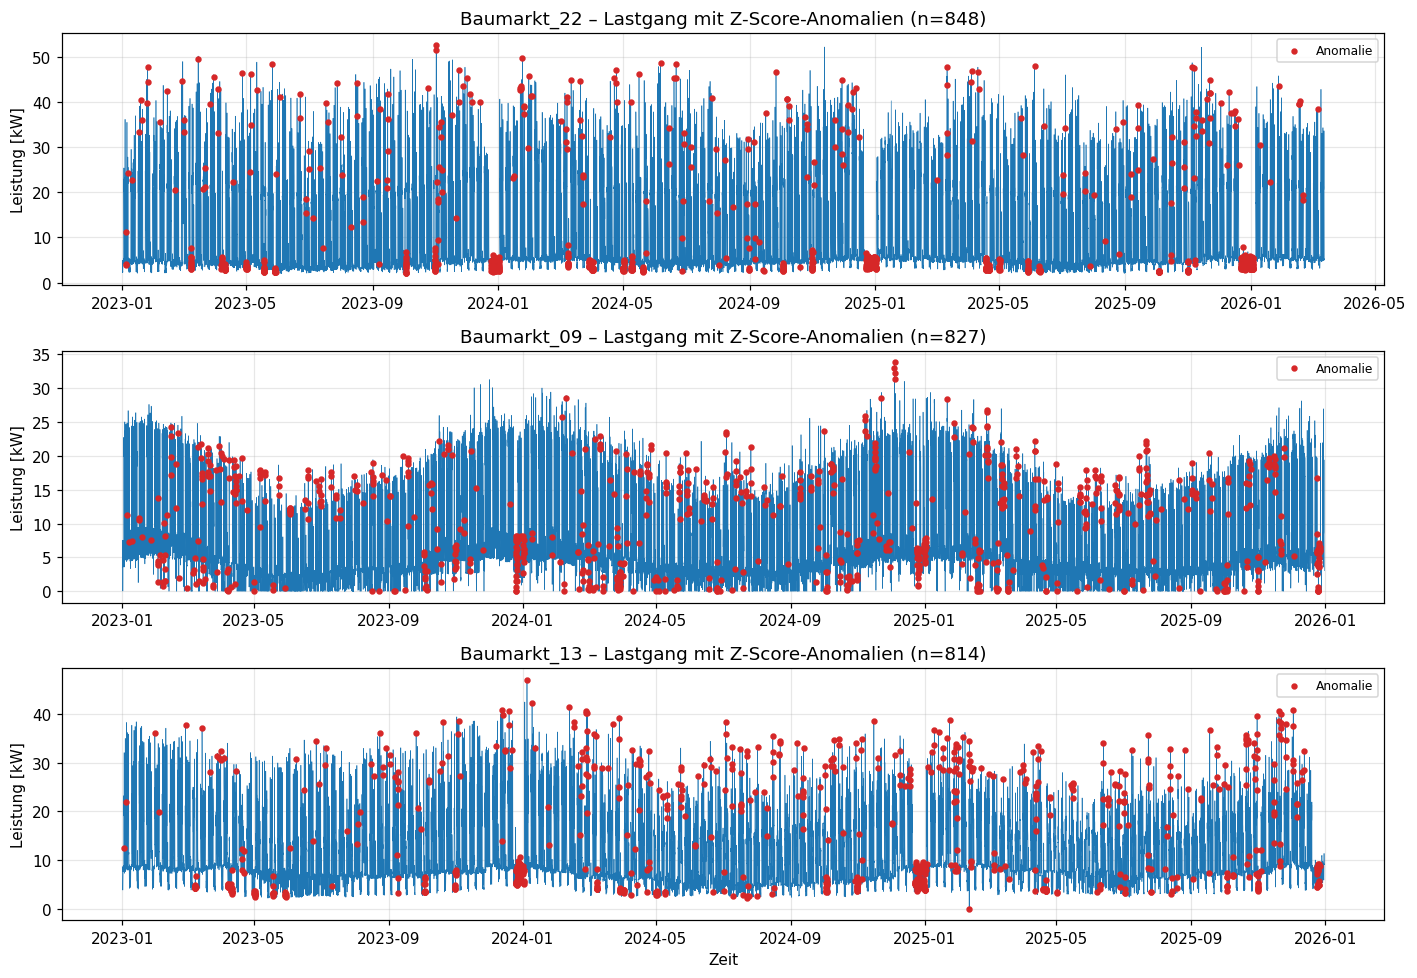

In [4]:
# Repräsentative Zähler: die drei mit den meisten Anomalien (auffälligste Fälle)
top_meters = (
    feat.groupby(level="meter_id")["is_anomaly"].sum().sort_values(ascending=False).head(3).index.tolist()
)
print("Gezeigte Zähler:", top_meters)

fig, axes = plt.subplots(len(top_meters), 1, figsize=(13, 9), sharex=False)
for ax, mid in zip(axes, top_meters):
    g = feat.xs(mid, level="meter_id")
    ax.plot(g.index, g["value_kw"], lw=0.4, color="tab:blue")
    an = g[g["is_anomaly"]]
    ax.scatter(an.index, an["value_kw"], color="tab:red", s=10, zorder=3, label="Anomalie")
    ax.set_title(f"{mid} – Lastgang mit Z-Score-Anomalien (n={len(an)})")
    ax.set_ylabel("Leistung [kW]")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Zeit")
savefig(fig, "baseline_zeitreihe_anomalien.png")
plt.show()

gespeichert: baseline_zscore_verteilung.png


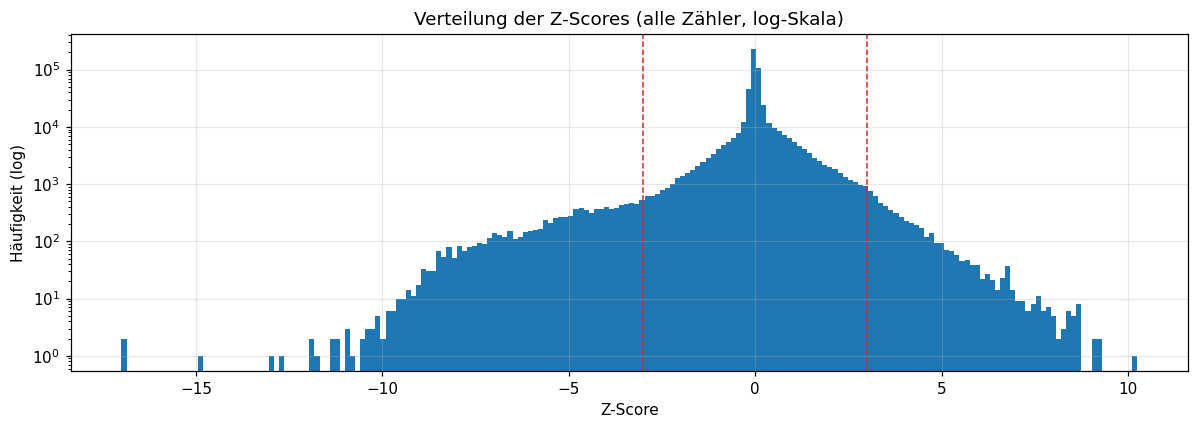

In [5]:
# Verteilung der Z-Scores (log-y zeigt die Tails) mit Schwellen
fig, ax = plt.subplots()
ax.hist(feat["zscore"].dropna(), bins=200, color="tab:blue")
for t in (-THRESH, THRESH):
    ax.axvline(t, color="tab:red", ls="--", lw=1)
ax.set_yscale("log")
ax.set_title("Verteilung der Z-Scores (alle Zähler, log-Skala)")
ax.set_xlabel("Z-Score")
ax.set_ylabel("Häufigkeit (log)")
savefig(fig, "baseline_zscore_verteilung.png")
plt.show()

gespeichert: baseline_anomalien_aggregiert.png


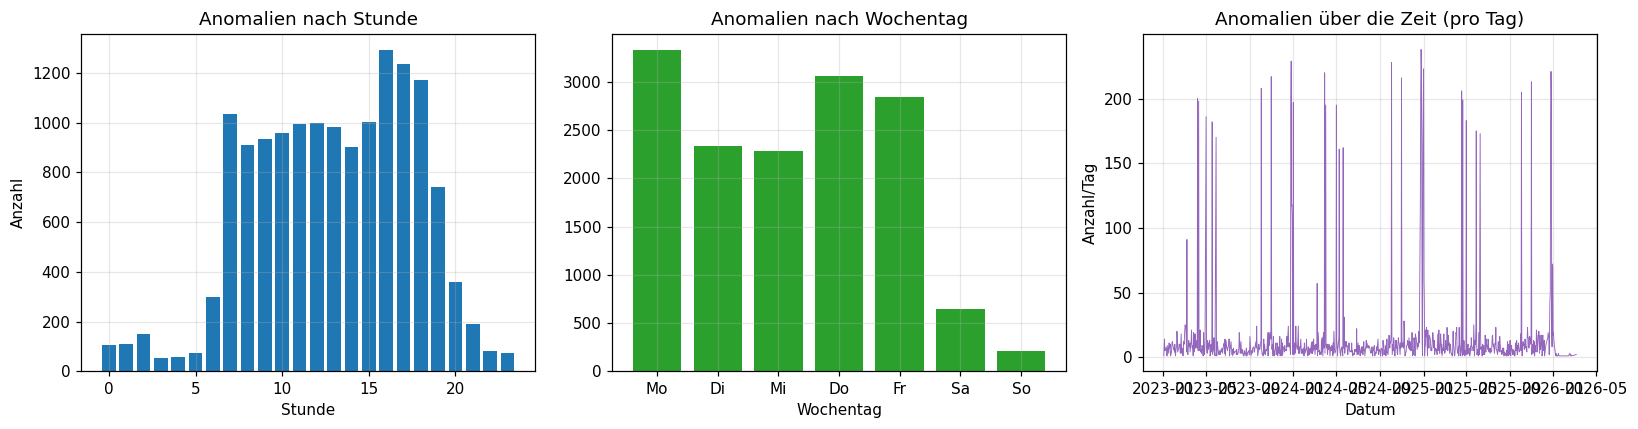

In [6]:
# Anomalien aggregiert nach Stunde, Wochentag, Datum
an = feat[feat["is_anomaly"]]
ts = an.index.get_level_values("timestamp")
by_hour = an.groupby("hour").size().reindex(range(24), fill_value=0)
by_dow = an.groupby("dow").size().reindex(range(7), fill_value=0)
by_date = pd.Series(1, index=ts).groupby(pd.Index(ts).date).sum()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(by_hour.index, by_hour.values)
axes[0].set_title("Anomalien nach Stunde")
axes[0].set_xlabel("Stunde")
axes[0].set_ylabel("Anzahl")
axes[1].bar(range(7), by_dow.values, color="tab:green")
axes[1].set_title("Anomalien nach Wochentag")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(LABELS)
axes[1].set_xlabel("Wochentag")
axes[2].plot(list(by_date.index), by_date.values, lw=0.6, color="tab:purple")
axes[2].set_title("Anomalien über die Zeit (pro Tag)")
axes[2].set_xlabel("Datum")
axes[2].set_ylabel("Anzahl/Tag")
savefig(fig, "baseline_anomalien_aggregiert.png")
plt.show()

## 4. Top-10-Anomalien mit Kontext

In [7]:
top10 = feat.assign(abs_z=feat["zscore"].abs()).sort_values("abs_z", ascending=False).head(10)
cols = ["value_kw", "zscore", "dow", "hour", "temperature", "price_eur_mwh"]
top10_view = top10[cols].copy()
top10_view["dow"] = top10_view["dow"].map(dict(enumerate(LABELS)))
top10_view.round(2)

value_kw  zscore dow  hour  \
meter_id    timestamp                                               
Baumarkt_16 2025-12-25 16:00:00+01:00      7.08  -17.00  Do    16   
Baumarkt_18 2025-12-25 16:00:00+01:00      7.08  -17.00  Do    16   
Baumarkt_07 2023-01-06 10:00:00+01:00     17.85  -14.88  Fr    10   
Baumarkt_23 2025-12-30 16:00:00+01:00     13.25  -13.03  Di    16   
Baumarkt_19 2025-12-29 12:00:00+01:00      1.34  -12.75  Mo    12   
Baumarkt_13 2024-04-04 18:00:00+02:00     15.15  -11.92  Do    18   
Baumarkt_15 2023-10-03 18:00:00+02:00      9.92  -11.86  Di    18   
            2023-10-03 09:00:00+02:00      8.02  -11.70  Di     9   
            2023-04-10 16:00:00+02:00     13.64  -11.41  Mo    16   
Baumarkt_08 2023-04-10 18:00:00+02:00     11.21  -11.34  Mo    18   

                                       temperature  price_eur_mwh  
meter_id    timestamp                                              
Baumarkt_16 2025-12-25 16:00:00+01:00          0.7          92.24  
Baumarkt_18 2025-12-25 16:00:00+01:00          0.7          92.24  
Baumarkt_07 2023-01-06 10:00:00+01:00          9.5         112.85  
Baumarkt_23 2025-12-30 16:00:00+01:00          1.5         109.10  
Baumarkt_19 2025-12-29 12:00:00+01:00         -1.6          87.66  
Baumarkt_13 2024-04-04 18:00:00+02:00         10.9          75.36  
Baumarkt_15 2023-10-03 18:00:00+02:00         16.4          35.72  
            2023-10-03 09:00:00+02:00         16.1           3.30  
            2023-04-10 16:00:00+02:00         15.6          -0.07  
Baumarkt_08 2023-04-10 18:00:00+02:00         15.3          44.58

## 5. Sensitivitätsanalyse der Schwelle

gespeichert: baseline_schwellen_sensitivitaet.png


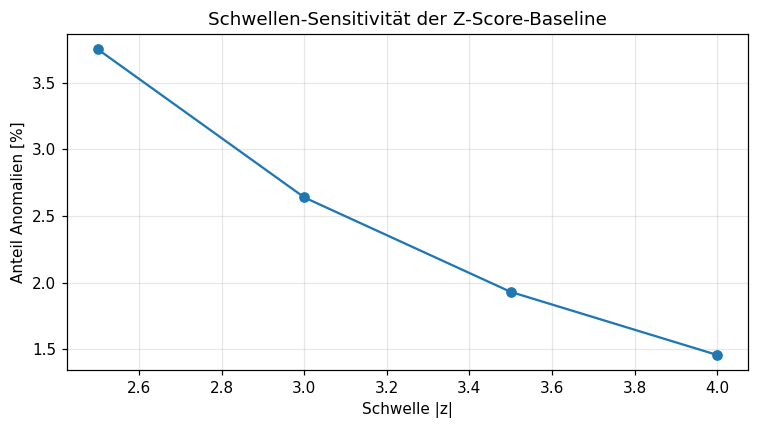

,n_anomalien,anteil_pct
threshold,,
2.5,20904,3.751
3.0,14712,2.640
3.5,10763,1.931
4.0,8124,1.458


In [8]:
rows = []
for t in (2.5, 3.0, 3.5, 4.0):
    flag = feat["zscore"].abs() > t
    rows.append({"threshold": t, "n_anomalien": int(flag.sum()),
                 "anteil_pct": round(flag.mean() * 100, 3)})
sens = pd.DataFrame(rows).set_index("threshold")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sens.index, sens["anteil_pct"], marker="o")
ax.set_title("Schwellen-Sensitivität der Z-Score-Baseline")
ax.set_xlabel("Schwelle |z|")
ax.set_ylabel("Anteil Anomalien [%]")
savefig(fig, "baseline_schwellen_sensitivitaet.png")
plt.show()
sens

## 6. Auswertung (Statistiken für die Befunde)

In [9]:
n_total = int(feat["is_anomaly"].sum())

# Zeitliche Häufung: Anteil der Anomalien an den Top-1%-Tagen
days_sorted = by_date.sort_values(ascending=False)
top1pct_days = max(1, int(len(by_date) * 0.01))
share_top_days = days_sorted.head(top1pct_days).sum() / n_total * 100

# Stunden-/Wochentag-Überrepräsentation (Anteil Anomalien vs. Anteil aller Stunden)
base_hour = feat.groupby("hour").size() / len(feat)
an_hour = by_hour / n_total
hour_lift = (an_hour / base_hour).sort_values(ascending=False)

base_dow = feat.groupby("dow").size() / len(feat)
an_dow = by_dow / n_total
dow_lift = (an_dow / base_dow)

print("Anomalien gesamt:", n_total)
print("Anteil an Top-1%%-Tagen (%d Tage): %.1f %%" % (top1pct_days, share_top_days))
print("\nStunden mit höchstem Lift (Anomalie-Anteil / Zeit-Anteil):")
print(hour_lift.head(5).round(2).to_string())
print("\nWochentag-Lift:")
print(dow_lift.round(2).rename(index=dict(enumerate(LABELS))).to_string())
print("\nAnomalie-Anteil je Zähler: median %.2f %%, max %.2f %% (Zähler %s)"
      % (rate.median(), rate.max(), rate.idxmax()))

Anomalien gesamt: 14712
Anteil an Top-1%-Tagen (9 Tage): 13.7 %

Stunden mit höchstem Lift (Anomalie-Anteil / Zeit-Anteil):
hour
16    2.11
17    2.02
18    1.91
7     1.69
15    1.64

Wochentag-Lift:
dow
Mo    1.58
Di    1.11
Mi    1.09
Do    1.46
Fr    1.36
Sa    0.31
So    0.10

Anomalie-Anteil je Zähler: median 2.84 %, max 3.15 % (Zähler Baumarkt_09)


## 7. Befunde & Limitationen der Baseline (für den Diskussions-Teil)

**Kennzahlen.** Bei |z| > 3: **14.712 Anomalien** über 23 Zähler. Anomalie-Anteil je
Zähler **median 2,84 %** (Spanne 1,69–3,15 %) — bemerkenswert **gleichmäßig** über die
Zähler. Diese Gleichmäßigkeit deutet auf einen **systematischen, methodischen** Effekt
hin, nicht auf zählerspezifische Defekte.

**Antworten auf die Leitfragen:**

1. **Anomalien pro Zähler:** ~640 im Schnitt, eng verteilt (1,69–3,15 %); kein einzelner
   „kaputter" Zähler dominiert.
2. **Zeitlich gehäuft oder verteilt?** Beides: ein moderater Event-Anteil (die obersten
   1 % der Tage tragen **13,7 %** der Anomalien), der Großteil aber über viele
   Werktags-Geschäftsstunden **verteilt** → überwiegend wiederkehrend, nicht
   event-getrieben.
3. **Über-/unterrepräsentierte Zeiten:** Konzentration auf **Geschäftsstunden** (16–18 Uhr
   Lift ≈ 2×, morgens 7 Uhr) und **Werktage** (Mo 1,58, Do 1,46, Fr 1,36);
   **Wochenenden praktisch frei** (Sa 0,31, So 0,10).
4. **False Positives in den Top-10?** Ja — der lehrreichste Befund: **alle Top-10 sind
   negative Residuen (Unterverbrauch) und fallen fast durchweg auf Feiertage/Schließtage**
   (25.12. Weihnachten, Ostermontag 10.04.2023, Tag der Deutschen Einheit 03.10.2023,
   Heilige Drei Könige 06.01.2023 [in Bayern Feiertag], Tage zwischen den Jahren). Das
   sind **keine Defekte**, sondern reguläre Schließungen → operativ **False Positives**.

### Limitationen der Baseline (→ Diskussion, motiviert die Hauptmethode)

- **L1 – Fat-tailed Residuen:** beobachtete Rate 2,84 % ≫ 0,27 % (Gauß-Erwartung), also
  ~10×. Die 3-Sigma-Intuition trägt nicht; die Schwelle muss **empirisch kalibriert**
  werden (s. Sensitivitätsanalyse), nicht aus der Normalverteilung abgeleitet.
- **L2 – STL kennt keine Feiertage (Hauptbefund):** STL (period=168) lernt die
  *regelmäßige* Wochenstruktur (inkl. niedriger Wochenenden → daher dort kaum Fehlalarme),
  aber **irreguläre Kalenderereignisse** nicht. An einem Feiertag erwartet das Saisonmodell
  volle Werktagslast → großes negatives Residuum → Fehlalarm. **Konsequenz:** Die
  Hauptmethode braucht **Feiertags-/Kalender-Awareness** — genau dafür liegen
  `is_holiday(_<state>)` bereits in `features.parquet`. Alternativ kann die
  LLM-Empfehlungsschicht „Feiertag" als Kontext erkennen und entschärfen.
- **L3 – Heteroskedastizität:** Die Residuenvarianz ist nicht konstant (Geschäftsstunden
  lauter als Nacht/Wochenende). Ein **einziger globaler σ je Zähler** über-flaggt
  Hochvarianz-Phasen und unter-flaggt ruhige. Das motiviert eine **zeit-/kontextabhängige
  Erwartungsvarianz** (ARIMA-Prädiktionsintervall) statt eines globalen Z-Scores.
- **L4 – Kein zeitlicher Kontext:** Ein isolierter Spike wird gleich behandelt wie eine
  mehrstündige anhaltende Abweichung; die Baseline punktet pro Zeitstempel, ohne
  Sequenz/Dauer zu bewerten.

### Konsequenzen für die ARIMA-Hauptmethode (Woche 3)

1. **Kalender-/Feiertagsregressoren** ins Saisonmodell (SARIMAX mit exogenem `is_holiday`)
   — die Top-10-Fehlalarme sollten damit verschwinden.
2. **Kontextabhängiges Prädiktionsintervall** statt globalem σ → adressiert L3.
3. **Schwelle empirisch kalibrieren** (fat tails), nicht 3-Sigma annehmen.
4. Baseline-Messlatte steht: ~2,8 % Flag-Rate, dominiert von erklärbaren Schließtagen —
   die Hauptmethode muss „weniger Pseudo-Anomalien bei gleichem/besserem Treffer auf echte
   Events" zeigen.